In [1]:
import numpy as np
import pandas as pd
from pymgrid import Microgrid
import matplotlib.pyplot as plt
from pymgrid.modules import  BatteryModule, LoadModule, RenewableModule, GridModule
from pymgrid.algos import RuleBasedControl

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
np.random.seed(42)
HORAS = 24

### Consumo dos Equipamentos Smart

In [3]:
# tudo em Kwh
standby = 0.03
perfil_residencia = np.array([
    0.8, 0.8, 0.7, 0.7, 0.8, 0.9, # 00h-05h (madrugada)
    1.2, 1.8, 1.5, 1.0, 0.9, 0.9, # 06h-11h (manhã: chuveiro, cafeteira)
    1.1, 1.0, 0.9, 0.9, 1.0, 1.4, # 12h-17h (tarde)
    2.2, 2.5, 2.0, 1.6, 1.2, 1.0, # 18h-23h (noite: TV, AC, chuveiro, lavadora)
])

In [4]:
carga_kwh = perfil_residencia + standby

### Geração Solar

In [5]:
horas = np.arange(HORAS)
geracao_solar = np.clip(3.5 * np.sin((horas - 6) * np.pi / 12), 0, None)
geracao_solar[(horas < 6) | (horas > 18)] = 0 # sem sol à noite

### Preço de compra e venda de energia da rede

In [18]:
tarifa_import = np.where((horas >= 18) & (horas <= 21), 1.20, 0.75) # ponta mais cara
tarifa_export = tarifa_import * 0.75 # venda de execedente vale menos

grid_ts = pd.DataFrame({
    "grid_price_import": tarifa_import,
    "grid_price_export": tarifa_export,
    "grid_co2": np.full(HORAS, 0.4),
})

In [7]:
# Eu posso criar uma lista com cada equipamento e associar 
# um valor de gasto a esse equipamento e a variação de ligação
# para o MPC escolher se a maquina vai ficar ligada ou não

###  Módulos da Residência

In [23]:
bateria = BatteryModule(
    min_capacity = 0.5,
    max_capacity = 15,
    max_charge = 3,
    max_discharge = 3,
    efficiency = 0.95,
    init_soc = 0.5,
)

carga_kwh_sim   = np.append(carga_kwh, carga_kwh[0])
geracao_solar_sim = np.append(geracao_solar, geracao_solar[0])
grid_ts_sim = pd.concat([grid_ts, grid_ts.iloc[[0]]], ignore_index=True)

carga = LoadModule(time_series=carga_kwh_sim)
solar = RenewableModule(time_series=geracao_solar_sim)
rede = GridModule(max_import=5, max_export=3, time_series=grid_ts_sim)


casa = Microgrid([bateria, ("pv", solar), carga, rede])
controlador = RuleBasedControl(casa)

In [24]:
def escolher_acao(casa,controlador):
    return controlador._get_action()

In [25]:
casa.reset()
controlador.reset()

{'load': [0.6719367588932805],
 'pv': [0.0],
 'balancing': [array([], dtype=float64)],
 'battery': [array([0.48275862, 0.48275862])],
 'grid': [array([0., 0., 0., 0.])],
 'balance': {},
 'other': {}}

### Simulação da residência

In [26]:
print("Simulando 1 dia na residência inteligente\n")

log = controlador.run()

Simulando 1 dia na residência inteligente



In [27]:
resumo = pd.DataFrame({
    "hora": range(len(log)),
    "consumo_kwh": log[("load", 0, "load_met")].round(2).values,
    "solar_kwh": log[("pv", 0, "renewable_current")].abs().round(2).values,
    "soc_bateria_%": (log[("battery", 0, "soc")] * 100).round(0).values,
    "compra_rede_kwh": log[("grid", 0, "grid_import")].round(2).values,
    "venda_rede_kwh": log[("grid", 0, "grid_export")].round(2).values,
    "custo_hora_R$": (-log[("balance", 0, "reward")]).round(2).values,
})

In [28]:

print(resumo.to_string(index=False))
print("\n--- Resumo do dia ---")
print(f"Consumo total:          {resumo['consumo_kwh'].sum():.2f} kWh")
print(f"Geração solar total:    {resumo['solar_kwh'].sum():.2f} kWh")
print(f"Energia comprada da rede: {resumo['compra_rede_kwh'].sum():.2f} kWh")
print(f"Energia vendida à rede:   {resumo['venda_rede_kwh'].sum():.2f} kWh")
print(f"Custo total do dia (R$): {resumo['custo_hora_R$'].sum():.2f}")
print(f"SOC final da bateria:   {resumo['soc_bateria_%'].iloc[-1]:.0f}%")


 hora  consumo_kwh  solar_kwh  soc_bateria_%  compra_rede_kwh  venda_rede_kwh  custo_hora_R$
    0         0.83       0.00           50.0             0.00             0.0          -0.00
    1         0.73       0.00           44.0             0.00             0.0          -0.00
    2         0.73       0.00           39.0             0.00             0.0          -0.00
    3         0.83       0.00           34.0             0.00             0.0          -0.00
    4         0.93       0.00           28.0             0.00             0.0          -0.00
    5         1.23       0.00           22.0             0.00             0.0          -0.00
    6         1.83       0.91           13.0             0.00             0.0          -0.00
    7         1.53       1.75            6.0             2.94             0.0           2.20
    8         1.03       2.47           26.0             1.71             0.0           1.28
    9         0.93       3.03           46.0             1.06         

In [14]:
tempo = resumo['hora'].to_numpy()
energia_consumida = resumo['consumo_kwh'].to_numpy()
energia_solar = resumo['solar_kwh'].to_numpy()

Text(0.5, 1.0, 'Energia Consumida ao Longo do Dia')

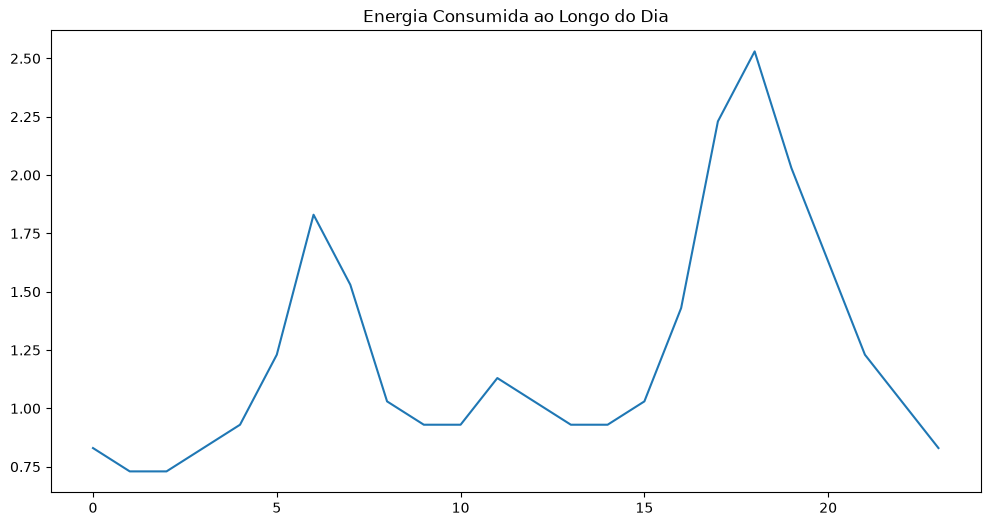

In [15]:
# ENERGIA CONSUMIDA AO LONGO DO DIA

plt.figure(figsize=(12, 6))
plt.plot(tempo, energia_consumida, label='Energia Consumida')
plt.title('Energia Consumida ao Longo do Dia')

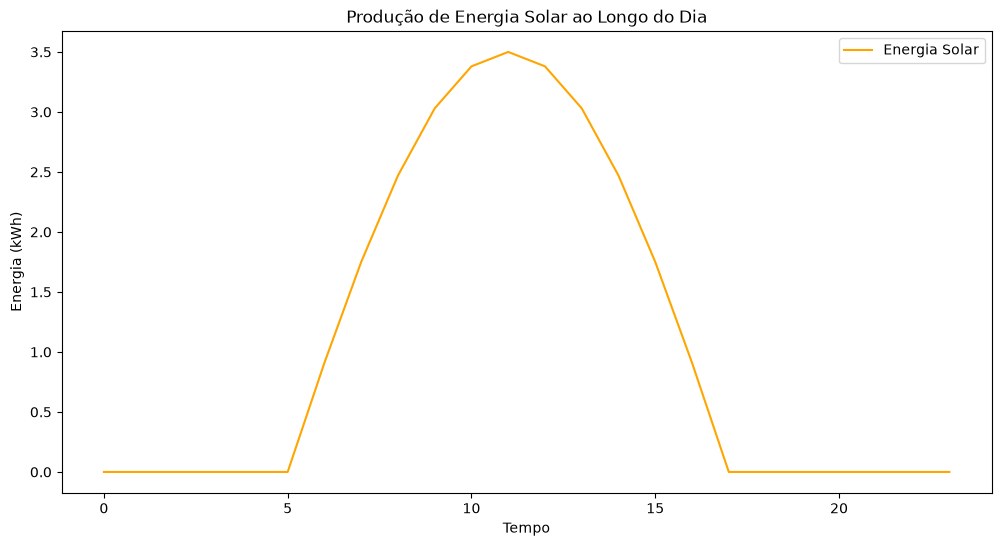

In [16]:
# PRODUÇÃO DE ENERGIA SOLAR AO LONGO DO DIA

plt.figure(figsize=(12,6))
plt.plot(tempo, energia_solar, label='Energia Solar', color='orange')
plt.title('Produção de Energia Solar ao Longo do Dia')
plt.xlabel('Tempo')
plt.ylabel('Energia (kWh)')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Porcentagem da Bateria ao Longo do Dia')

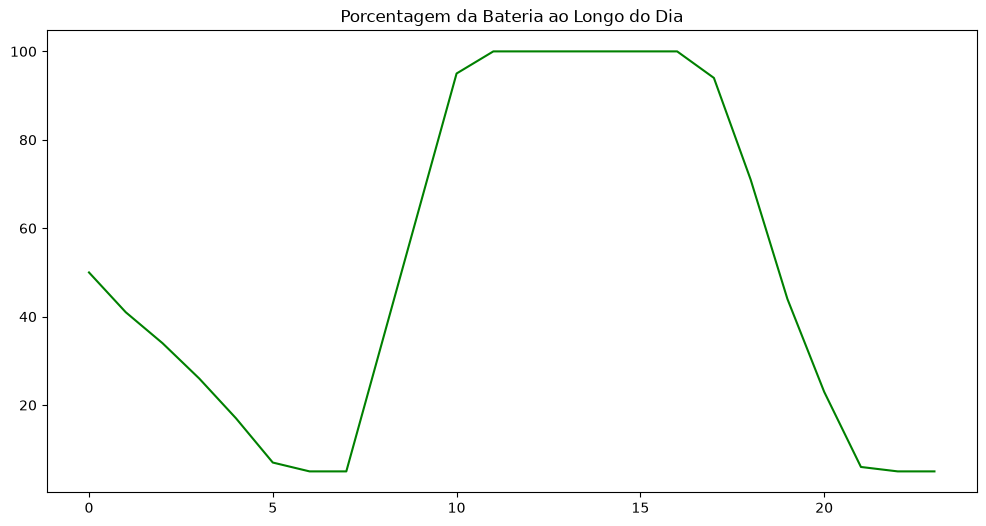

In [17]:
# PORCENTAGEM DA BATERIA AO LONGO DO DIA

plt.figure(figsize=(12,6))
plt.plot(tempo, resumo['soc_bateria_%'], label='SOC da Bateria', color='green')
plt.title('Porcentagem da Bateria ao Longo do Dia')